# 05 — Cross-Subject Generalization

## Objective

Evaluate whether the fixed CSP + LDA motor-imagery baseline can generalize to a completely unseen subject.

For each cross-validation fold, EEG from one subject will be completely held out. CSP and LDA will be fitted using only the remaining subjects, and the fitted pipeline will then be evaluated on the unseen subject.

The preprocessing protocol and model settings are kept fixed from the Week 5 baseline. No hyperparameters are tuned for this experiment.

### Imports

In [1]:
from pathlib import Path
import sys

import mne
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score

mne.set_log_level("WARNING")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurosignallab.preprocessing import preprocess_subject

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eegbci"

### Create multi-subject dataset

In [2]:
subjects = range(1, 110)

X_parts = []
y_parts = []
group_parts = []

for subject in subjects:

    X_subject, y_subject, metadata_subject = preprocess_subject(
        subject=subject,
        data_dir=DATA_DIR
    )

    X_parts.append(X_subject)
    y_parts.append(y_subject)
    group_parts.append(
        metadata_subject["subject"].to_numpy() #Which subject produced which trials
    )

X = np.concatenate(X_parts, axis=0) #Concatentate trials, trials not at 160Hz get resampled
y = np.concatenate(y_parts)
groups = np.concatenate(group_parts)

del X_parts, y_parts, group_parts #Clear space

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Number of subjects:", len(np.unique(groups)))

/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(
/Users/heihei/Desktop/neurosignallab/src/neurosignallab/preprocessing.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_run = mne.io.read_raw_edf(


X shape: (4898, 64, 481)
y shape: (4898,)
groups shape: (4898,)
Number of subjects: 109


## Leave-One-Subject-Out Cross-Validation 

Use LeaveOneGroupOut with subject identity as the grouping variable.

For every fold, all trials from one subject are held out for testing,
while all trials from the remaining subjects are used for training.

The held-out subject therefore contributes no data to model fitting.

### Create one fold

In [3]:
cv = LeaveOneGroupOut()

train_idx, test_idx = next(
    cv.split(X, y, groups) #Use next() because we only want to load one fold first (with one training and one test set)
)

print("Held-out subject:", np.unique(groups[test_idx]))
print("Number of training subjects:", len(np.unique(groups[train_idx])))
print("Training trials:", len(train_idx))
print("Test trials:", len(test_idx))

Held-out subject: [1]
Number of training subjects: 108
Training trials: 4853
Test trials: 45


### Define CSP and LDA in pipiline

In [4]:
csp = CSP(
    n_components=4,
    log=True
)

lda = LinearDiscriminantAnalysis()

model = Pipeline([
    ("csp", csp),
    ("lda", lda)
])

### Test CSP and LDA on one fold

In [5]:
model.fit(
    X[train_idx],
    y[train_idx]
)

y_pred = model.predict(
    X[test_idx]
)

print(
    "Balanced accuracy:",
    balanced_accuracy_score(y[test_idx], y_pred)
)

print(
    "Accuracy:",
    accuracy_score(y[test_idx], y_pred)
)

Balanced accuracy: 0.6304347826086957
Accuracy: 0.6222222222222222


### Full Leave-One-Subject-Out Evaluation

In [6]:
results = []

for train_idx, test_idx in cv.split(X, y, groups): #Gives all folds

    model.fit(
        X[train_idx],
        y[train_idx]
    )

    y_pred = model.predict(
        X[test_idx]
    )

    results.append({
        "subject": groups[test_idx[0]], #print held out subject
        "balanced_accuracy": balanced_accuracy_score(
            y[test_idx],
            y_pred
        ),
        "accuracy": accuracy_score(
            y[test_idx],
            y_pred
        )
    })

results_df = pd.DataFrame(results)

results_df

,subject,balanced_accuracy,accuracy
0,1,0.630435,0.622222
1,2,0.776680,0.777778
2,3,0.485178,0.488889
3,4,0.606719,0.600000
4,5,0.500000,0.466667
...,...,...,...
104,105,0.500988,0.511111
105,106,0.541667,0.511111
106,107,0.568452,0.577778
107,108,0.782609,0.777778


### Cohort summary of cross-subject generalization

In [7]:
print("Number of results:", len(results_df))
print("Number of subjects:", results_df["subject"].nunique())

print("Mean balanced accuracy:", results_df["balanced_accuracy"].mean())
print("Median balanced accuracy:", results_df["balanced_accuracy"].median())
print("Minimum balanced accuracy:", results_df["balanced_accuracy"].min())
print("Maximum balanced accuracy:", results_df["balanced_accuracy"].max())

Number of results: 109
Number of subjects: 109
Mean balanced accuracy: 0.5654474968719222
Median balanced accuracy: 0.5297619047619048
Minimum balanced accuracy: 0.4258893280632411
Maximum balanced accuracy: 0.8893280632411067


## Compare results to Week 5

### Load Week 5 results

In [8]:

within_results = pd.read_csv(
    PROJECT_ROOT / "results" / "csp_lda_within_subject_summary.csv",
    index_col=0
)

within_results = within_results.reset_index() #Remove subject index

within_results = within_results[
    ["subject", "balanced_accuracy"]
].rename(
    columns={"balanced_accuracy": "within_subject_ba"}
) #Rename to fit into analysis


### Prepare Week 6 results

In [9]:

cross_results = results_df[
    ["subject", "balanced_accuracy"]
].rename(
    columns={"balanced_accuracy": "cross_subject_ba"}
)


### Compare Week 5 and Week 6

In [10]:

comparison_df = within_results.merge(
    cross_results,
    on="subject"
)

comparison_df["difference"] = (
    comparison_df["cross_subject_ba"]
    - comparison_df["within_subject_ba"]
)

print(
    "Mean change:",
    comparison_df["difference"].mean()
)

print(
    "Median change:",
    comparison_df["difference"].median()
)

comparison_df


Mean change: -0.03185299824967376
Median change: -0.020551006964050433


,subject,within_subject_ba,cross_subject_ba,difference
0,1,0.681548,0.630435,-0.051113
1,2,0.794643,0.776680,-0.017963
2,3,0.517857,0.485178,-0.032679
3,4,0.491071,0.606719,0.115648
4,5,0.541667,0.500000,-0.041667
...,...,...,...,...
104,105,0.574405,0.500988,-0.073417
105,106,0.604167,0.541667,-0.062500
106,107,0.553571,0.568452,0.014881
107,108,0.693452,0.782609,0.089156


### Check for improvement

In [14]:
print(
    "Improved:",
    np.sum(comparison_df["difference"] > 0)
)

print(
    "Worsened:",
    np.sum(comparison_df["difference"] < 0)
)

Improved: 46
Worsened: 63


### Comparison plot

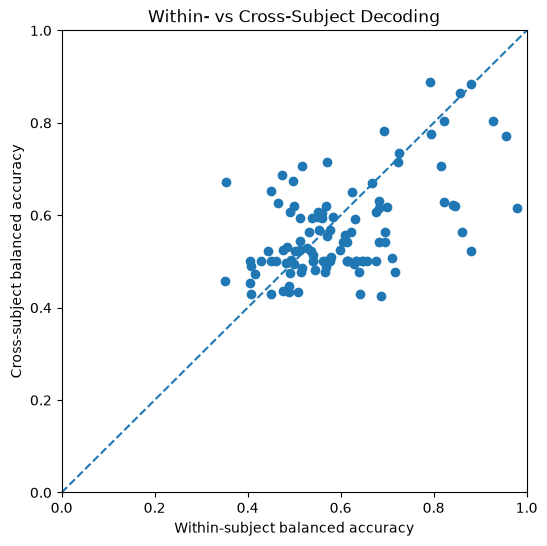

In [13]:

plt.figure(figsize=(6, 6))

plt.scatter(
    comparison_df["within_subject_ba"],
    comparison_df["cross_subject_ba"]
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Within-subject balanced accuracy")
plt.ylabel("Cross-subject balanced accuracy")
plt.title("Within- vs Cross-Subject Decoding")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()


### Save Week 6 data

In [15]:

cross_path = (
    PROJECT_ROOT
    / "results"
    / "csp_lda_cross_subject_summary.csv"
)

comparison_path = (
    PROJECT_ROOT
    / "results"
    / "within_vs_cross_subject_comparison.csv"
)

if not cross_path.exists():
    results_df.to_csv(cross_path, index=False)

if not comparison_path.exists():
    comparison_df.to_csv(comparison_path, index=False)



## Summary

The fixed CSP + LDA baseline was evaluated using leave-one-subject-out
cross-validation across all 109 subjects.

For every fold, one subject was completely excluded from model fitting.
CSP and LDA were fitted using EEG from the remaining 108 subjects and
then evaluated on the unseen subject.

Cross-subject decoding achieved a mean balanced accuracy of
approximately 0.565 and a median balanced accuracy of approximately
0.530.

The corresponding Week 5 within-subject baseline achieved a mean
balanced accuracy of approximately 0.597 and a median balanced accuracy
of approximately 0.568.

For each subject, cross-subject balanced accuracy was compared directly
with their within-subject balanced accuracy. The mean paired change was
approximately -0.032 and the median change was approximately -0.021.

Cross-subject performance was higher for 46 subjects and lower for
63 subjects.

These results indicate that CSP + LDA retains some ability to decode
motor imagery in completely unseen subjects, but performance is lower
on average when subject-specific training data are removed.


The effect is heterogeneous across subjects. Some individuals benefit
from the large population-level training set, while others perform
considerably better when the model is trained using their own EEG.

This suggests that motor-imagery EEG contains both transferable
population-level structure and subject-specific structure. However,
the current experiment does not determine the physiological or
statistical cause of the individual differences.

Statistical significance relative to
chance and statistical testing of the within- versus cross-subject
difference have not yet been performed.